<a href="https://colab.research.google.com/github/korbinianbauer/meshtastic-throttling-experiments/blob/main/Meshtastic___Hop_Cost_factor_Mesh_Topology_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random

def generate_random_scenario(min_city_nodes=0, max_city_nodes=500,
                             min_scattered_nodes=0, max_scattered_nodes=1000,
                             min_sender_range=10, max_sender_range=50,
                             min_pos=-200, max_pos=200,
                             min_cities=0, max_cities=3):
    """
    Generates a random scenario dictionary.

    Args:
        min_city_nodes: Minimum number of nodes in each city.
        max_city_nodes: Maximum number of nodes in each city.
        min_scattered_nodes: Minimum number of scattered nodes.
        max_scattered_nodes: Maximum number of scattered nodes.
        min_sender_range: Minimum communication range for the sender node.
        max_sender_range: Maximum communication range for the sender node.
        min_pos: Minimum coordinate value for node positions and city centers.
        max_pos: Maximum coordinate value for node positions and city centers.
        min_cities: Minimum number of cities.
        max_cities: Maximum number of cities.

    Returns:
        A dictionary representing the random scenario.
    """
    num_cities = random.randint(min_cities, max_cities)
    num_nodes_city_per_city = random.randint(min_city_nodes, max_city_nodes)
    num_nodes_city = num_nodes_city_per_city * num_cities
    num_nodes_scattered = random.randint(min_scattered_nodes, max_scattered_nodes)
    sender_range = random.randint(min_sender_range, max_sender_range)
    sender_node_pos = (random.uniform(min_pos, max_pos), random.uniform(min_pos, max_pos))

    city_centers = [(random.uniform(min_pos, max_pos), random.uniform(min_pos, max_pos)) for _ in range(num_cities)]

    title = f'Random Scenario: Cities={num_cities}, Nodes per City={num_nodes_city_per_city}, Scattered Nodes={num_nodes_scattered}, Sender Range={sender_range}'

    return {
        'title': title,
        'num_cities': num_cities,
        'num_nodes_city_per_city': num_nodes_city_per_city,
        'num_nodes_scattered': num_nodes_scattered,
        'sender_range': sender_range,
        'sender_node_pos': sender_node_pos,
        'city_centers': city_centers
    }

In [ ]:
import numpy as np

def generate_node_coords(scenario):
    """Generates node coordinates based on a scenario dictionary."""
    num_nodes_city_per_city = scenario['num_nodes_city_per_city']
    num_nodes_scattered = scenario['num_nodes_scattered']
    city_centers = scenario['city_centers']

    # Generate city nodes around each city center
    city_nodes_coords = []
    for center in city_centers:
        x_city = np.random.normal(center[0], 15, num_nodes_city_per_city)
        y_city = np.random.normal(center[1], 15, num_nodes_city_per_city)
        city_nodes_coords.append(np.stack((x_city, y_city), axis=-1))

    # Concatenate city node coordinates if there are any cities
    if city_nodes_coords:
        city_nodes_coords = np.concatenate(city_nodes_coords, axis=0)
    else:
        city_nodes_coords = np.empty((0, 2)) # Handle the case with no cities

    # Add some nodes evenly scattered all over the map
    x_scattered = np.random.uniform(-200, 200, num_nodes_scattered)
    y_scattered = np.random.uniform(-200, 200, num_nodes_scattered)
    scattered_nodes_coords = np.stack((x_scattered, y_scattered), axis=-1)


    # Combine all node coordinates
    nodes_coords = np.concatenate((city_nodes_coords, scattered_nodes_coords), axis=0)


    return nodes_coords

In [ ]:
import numpy as np

def get_covering_nodes(node, nodes, verbose=False):
  covering_nodes = set()
  for other_node in nodes:
          if verbose: print(f'Checking coverage between {node} and {other_node}')
          if node['index'] == other_node['index']:# Don't check coverage with itself
            if verbose: print(f'Not comparing Node {node["index"]} to itself')
            continue
          #if node['hop'] is not None: # Don't check coverage if current node has already sent
          #  if verbose: print(f'Node {node["index"]} already sent')
          #  continue
          if other_node['hop'] is None:# Don't check coverage if other node hasn't sent
            if verbose: print(f'Other Node {other_node["index"]} has not sent yet')
            continue
          if np.linalg.norm(node['pos'] - other_node['pos']) <= other_node['range']:
              covering_nodes.add(other_node['index'])
              if verbose: print(f'Node {node["index"]} covered by {other_node["index"]}')
  return covering_nodes

def getDensityFactor(node, nodes, verbose=False):
  # Count the number of nodes within 30km range
  # Nodes iin a very dense area should have less range, since there's probably also a lot of buildings
  range = 30
  covering_nodes = set()
  for other_node in nodes:
          if verbose: print(f'Checking coverage between {node} and {other_node}')
          if node['index'] == other_node['index']:# Don't check coverage with itself
            if verbose: print(f'Not comparing Node {node["index"]} to itself')
            continue
          if np.linalg.norm(node['pos'] - other_node['pos']) <= range:
              covering_nodes.add(other_node['index'])
              if verbose: print(f'Node {node["index"]} covered by {other_node["index"]}')
  if verbose: print(f'Number of nodes within {range}km range: {len(covering_nodes)}')
  # reduce range by 0.25% for each node in range
  density_factor = 0.9975**len(covering_nodes)
  if verbose: print(f'Density factor: {density_factor}')
  return density_factor

def guessInitChannelUtil(node, nodes, capacity_scale_factor=100, verbose=False):
    """
    Guesses the initial channel utilization for a node based on the density of nodes around it.

    Args:
        node: The node for which to guess the channel utilization.
        nodes: A list of all nodes in the simulation.
        capacity_scale_factor: The number of nodes in range at which channel utilization reaches 100%.
        verbose: Whether to print verbose output.

    Returns:
        A float representing the estimated channel utilization (0.0 to 1.0).
    """
    range = 30  # Use the same range as getDensityFactor
    covering_nodes = set()
    for other_node in nodes:
        if verbose: print(f'Checking coverage between {node} and {other_node}')
        if np.linalg.norm(node['pos'] - other_node['pos']) <= range:
            covering_nodes.add(other_node['index'])
            if verbose: print(f'Node {node["index"]} covered by {other_node["index"]}')

    num_nodes_in_range = len(covering_nodes)
    if verbose: print(f'Number of nodes within {range}km range (including self): {num_nodes_in_range}')

    # Scale channel utilization linearly with the number of nodes in range
    channel_utilization = min(1.0, num_nodes_in_range / capacity_scale_factor)

    if verbose: print(f'Channel utilization: {channel_utilization}')
    return channel_utilization

In [ ]:
import numpy as np
import timeit
from scipy.spatial.distance import cdist # A highly optimized way to compute distance matrices

def runSimulation_fast(nodes_coords, sender_node_pos, sender_range, min_range, max_range, capacity_scale_factor=100):
    """
    A vectorized and optimized version of the simulation.
    """
    num_nodes = len(nodes_coords)
    # Ensure nodes_coords is a NumPy array for vectorized operations
    nodes_coords = np.array(nodes_coords)

    # =========================================================================
    # 1. Pre-computation and Vectorized Initialization
    # =========================================================================

    # Calculate the all-pairs distance matrix ONCE. This is the biggest win.
    # dist_matrix[i, j] will be the distance between node i and node j.
    dist_matrix = cdist(nodes_coords, nodes_coords)

    # --- Vectorize getDensityFactor and guessInitChannelUtil ---
    # Count nodes within 30km for all nodes at once
    # We subtract 1 to exclude the node itself from its own density count
    density_counts = np.sum(dist_matrix <= 30, axis=1) - 1

    # Calculate density factor for all nodes
    density_factors = 0.9975**density_counts

    # Calculate initial channel utilization for all nodes
    # We use density_counts + 1 because the original included the node itself
    ch_util = np.minimum(1.0, (density_counts + 1) / capacity_scale_factor)

    # =========================================================================
    # 2. Initialize Node State Arrays
    # =========================================================================
    # Use NumPy arrays instead of a list of dicts for performance.
    # We'll use a sentinel value like -2 for 'None' to keep arrays numeric.
    # hop: -2=not sent, -1=original sender, 0,1,2...=hop number
    hops = np.full(num_nodes, -2, dtype=np.int8)
    ranges = np.zeros(num_nodes, dtype=np.float32)

    # --- Set up the initial sender ---
    distances_from_pos = cdist(nodes_coords, np.array([sender_node_pos]))
    sender_index = np.argmin(distances_from_pos)

    hops[sender_index] = -1
    ranges[sender_index] = sender_range

    # =========================================================================
    # 3. Optimized Main Simulation Loop
    # =========================================================================
    for hop in range(7):
        # Identify nodes that have already sent (potential transmitters)
        # and those that have not (potential receivers/candidates)
        has_sent_mask = hops > -2
        not_sent_mask = ~has_sent_mask

        # If no nodes are left to become relayers, we can stop early.
        if not np.any(not_sent_mask):
            break

        # --- Vectorized get_covering_nodes ---
        # Build a boolean matrix where `is_covered_matrix[i, j]` is True
        # if node i (a potential receiver) is covered by node j (a sender).

        # Condition 1: Distance must be <= range of the sender.
        # This uses broadcasting: dist_matrix (N,N) <= ranges (N,)
        # compares each column of the distance matrix with the corresponding range.
        coverage_potential = dist_matrix <= ranges

        # Condition 2: The covering node `j` must have already sent.
        # We combine these to get the final coverage matrix for this hop.
        is_covered_matrix = coverage_potential & has_sent_mask

        # Now, for each node `i` that has not sent, count how many nodes cover it.
        # We set counts for nodes that have already sent to -1 to ignore them.
        num_covering_nodes = np.sum(is_covered_matrix, axis=1)
        num_covering_nodes[has_sent_mask] = -1 # Invalidate already-sent nodes

        # Relay candidates are non-sending nodes covered by exactly one node.
        relay_candidate_indices = np.where(num_covering_nodes == 1)[0]

        if len(relay_candidate_indices) == 0:
            break

        # --- Optimized selection loop (`while len(relay_candidate_indizes)`) ---
        # This part is iterative, so a loop is still needed, but each step is now fast.

        # Create a set for efficient removal of candidates
        candidates_set = set(relay_candidate_indices)

        while candidates_set:
            # Re-convert to list/array for indexing
            current_candidates = np.array(list(candidates_set))

            # --- Find the best relayer (farthest from its single covering node) ---
            # For each candidate, find the index of the node that covers it
            # This is a bit tricky, but argmax on the boolean mask works because there's only one True value.
            covering_node_indices = np.argmax(is_covered_matrix[current_candidates, :], axis=1)

            # Get the distances for each candidate to its covering node
            distances = dist_matrix[current_candidates, covering_node_indices]

            # Find the candidate with the maximum distance
            best_candidate_local_idx = np.argmax(distances)
            relayer_idx = current_candidates[best_candidate_local_idx]

            # --- Update the chosen relayer's state ---
            hops[relayer_idx] = hop
            ranges[relayer_idx] = np.random.uniform(min_range, max_range) * density_factors[relayer_idx]

            # Remove the chosen relayer from the candidate set
            candidates_set.remove(relayer_idx)
            if not candidates_set:
                break

            # --- Invalidate other candidates now covered by the new relayer ---
            remaining_candidates = np.array(list(candidates_set))

            # Check which of the remaining candidates are covered by our new relayer
            newly_covered_mask = dist_matrix[remaining_candidates, relayer_idx] <= ranges[relayer_idx]

            # These newly covered candidates now have 2+ covering nodes, so they are invalid.
            invalidated_candidates = remaining_candidates[newly_covered_mask]

            # Remove them from the set for the next iteration of the while loop
            candidates_set.difference_update(invalidated_candidates)

    # =========================================================================
    # 4. Final Hops Away Calculation (Vectorized)
    # =========================================================================

    # Re-calculate the final coverage matrix based on all nodes that ever sent
    has_sent_mask = hops > -2
    final_coverage_matrix = (dist_matrix <= ranges) & has_sent_mask

    # Create a matrix of hop values from covering nodes
    # Use a large number (infinity) where there is no coverage
    hop_values = np.where(final_coverage_matrix, hops + 1, np.inf)

    # For each node, the number of hops away is the minimum of the hops of the nodes covering it
    final_hops_away = np.min(hop_values, axis=1)

    # =========================================================================
    # 5. Reconstruct the list of dictionaries for the final output
    # =========================================================================

    final_nodes = []
    for i in range(num_nodes):
        # Find which nodes cover this one
        covered_by_indices = np.where(final_coverage_matrix[i, :])[0]

        final_nodes.append({
            'index': i,
            'pos': nodes_coords[i],
            'hop': int(hops[i]) if hops[i] > -2 else None,
            'hops_away': int(final_hops_away[i]) if final_hops_away[i] != np.inf else None,
            'range': ranges[i] if ranges[i] > 0 else None,
            'covered_by': set(covered_by_indices),
            'ch_util': ch_util[i]
        })

    return final_nodes

In [ ]:
from visualizePropagation import visualizePropagation
from visualizeChannelUtilization import visualizeChannelUtilization_fast
from fit_hop_distance_behaviour import fit_hop_distance_behaviour

In [ ]:
scenario_dense_uniform_mesh = {'title': 'Dense Uniform Mesh', 'num_cities': 0, 'num_nodes_city_per_city': 0, 'num_nodes_scattered': 1000, 'sender_range': 30, 'sender_node_pos': (-15, -15), 'city_centers': []}
scenario_sparse_uniform_mesh = {'title': 'Sparse Uniform Mesh', 'num_cities': 0, 'num_nodes_city_per_city': 0, 'num_nodes_scattered': 200, 'sender_range': 30, 'sender_node_pos': (-15, -15), 'city_centers': []}
scenario_city_and_country_mesh = {'title': 'City + Country Mesh', 'num_cities': 1, 'num_nodes_city_per_city': 300, 'num_nodes_scattered': 400, 'sender_range': 10, 'sender_node_pos': (-15, -15), 'city_centers': [(0,0)]}
scenario_city_only_mesh = {'title': 'City Only Mesh', 'num_cities': 1, 'num_nodes_city_per_city': 300, 'num_nodes_scattered': 200, 'sender_range': 10, 'sender_node_pos': (-15, -15), 'city_centers': [(0,0)]}
scenario_city_and_country_mesh_sender_rural = {'title': 'City + Country Mesh, Rural sender', 'num_cities': 1, 'num_nodes_city_per_city': 300, 'num_nodes_scattered': 400, 'sender_range': 30, 'sender_node_pos': (-10, -110), 'city_centers': [(0,0)]}
scenario_super_dense_uniform_mesh = {'title': 'Dense Uniform Mesh', 'num_cities': 0, 'num_nodes_city_per_city': 0, 'num_nodes_scattered': 10000, 'sender_range': 30, 'sender_node_pos': (-15, -15), 'city_centers': []}

In [ ]:
num_runs = 1000
min_range = 1
max_range = 100


import time
runs = []
start_time = time.time()
for i in range(num_runs):
  print(f"Running scenario {i}/{num_runs}")
  scenario = generate_random_scenario()
  nodes_coords = generate_node_coords(scenario)

  nodes = runSimulation_fast(nodes_coords, scenario['sender_node_pos'], scenario['sender_range'], min_range, max_range)

  #nodes = runSimulation(nodes_coords, scenario['sender_node_pos'], scenario['sender_range'], min_range, max_range, verbose=False)

  run = {'nodes': nodes, 'scenario': scenario}
  runs.append(run)

print(f"Completed {len(runs)} runs in {time.time() - start_time:.1f} seconds. Average time per run: {(time.time() - start_time) / len(runs):.2f} seconds.")

Running scenario 0/1000
Running scenario 1/1000
Running scenario 2/1000
Running scenario 3/1000
Running scenario 4/1000
Running scenario 5/1000
Running scenario 6/1000
Running scenario 7/1000
Running scenario 8/1000
Running scenario 9/1000
Running scenario 10/1000
Running scenario 11/1000
Running scenario 12/1000
Running scenario 13/1000
Running scenario 14/1000
Running scenario 15/1000
Running scenario 16/1000
Running scenario 17/1000
Running scenario 18/1000
Running scenario 19/1000
Running scenario 20/1000
Running scenario 21/1000
Running scenario 22/1000
Running scenario 23/1000
Running scenario 24/1000
Running scenario 25/1000
Running scenario 26/1000
Running scenario 27/1000
Running scenario 28/1000
Running scenario 29/1000
Running scenario 30/1000
Running scenario 31/1000
Running scenario 32/1000
Running scenario 33/1000
Running scenario 34/1000
Running scenario 35/1000
Running scenario 36/1000
Running scenario 37/1000
Running scenario 38/1000
Running scenario 39/1000
Running sc

In [ ]:
num_runs_no_coverage = 0
num_runs_no_topology_fit = 0
for i in range(len(runs)):

  runs[i]['a_fit_relayers'] = None
  runs[i]['b_fit_relayers'] = None
  runs[i]['a_fit_nodes_away'] = None
  runs[i]['b_fit_nodes_away'] = None

  run = runs[i]
  nodes = run['nodes']
  scenario = run['scenario']
  # Check if at least one node was covered (hops_away is not None for at least one node)
  if all(node['hops_away'] is None for node in nodes):
      num_runs_no_coverage += 1
      #print(f"Skipping run {i} as no nodes were covered.")
      continue

  #visualizePropagation(nodes)
  a_fit_relayers, b_fit_relayers, a_fit_nodes_away, b_fit_nodes_away = fit_hop_distance_behaviour(nodes)

  # Check if fitted parameters are None (happens if no nodes were covered)
  if a_fit_relayers is None or b_fit_relayers is None or a_fit_nodes_away is None or b_fit_nodes_away is None:
      num_runs_no_topology_fit += 1
      #print(f"Skipping run {i} due to inability to fit power function.")
      continue

  # Store all 4 params and scenario in run
  runs[i]['a_fit_relayers'] = a_fit_relayers
  runs[i]['b_fit_relayers'] = b_fit_relayers
  runs[i]['a_fit_nodes_away'] = a_fit_nodes_away
  runs[i]['b_fit_nodes_away'] = b_fit_nodes_away

print(f"Processed {len(runs)} runs. {num_runs_no_coverage} runs skipped due to no nodes being covered. {num_runs_no_topology_fit} runs skipped due to inability to fit power function.")

/content/fit_hop_distance_behaviour.py:49: OptimizeWarning: Covariance of the parameters could not be estimated
  params_nodes_away, _ = curve_fit(power_function, x_data_nodes_away, y_data_nodes_away, p0=p0)
/content/fit_hop_distance_behaviour.py:78: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(power_function, x_data_relayers, y_data_relayers, p0=p0)


Processed 1000 runs. 0 runs skipped due to no nodes being covered. 161 runs skipped due to inability to fit power function.


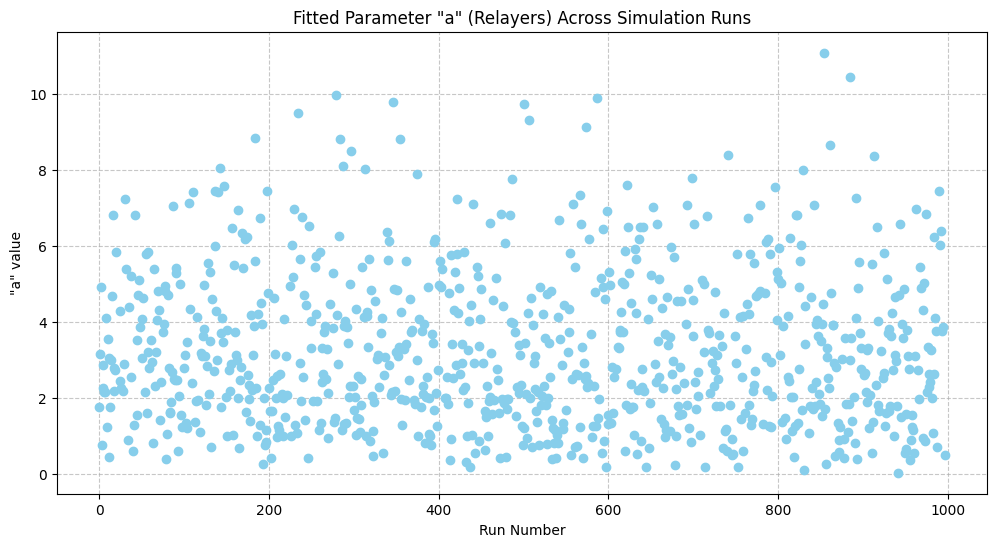

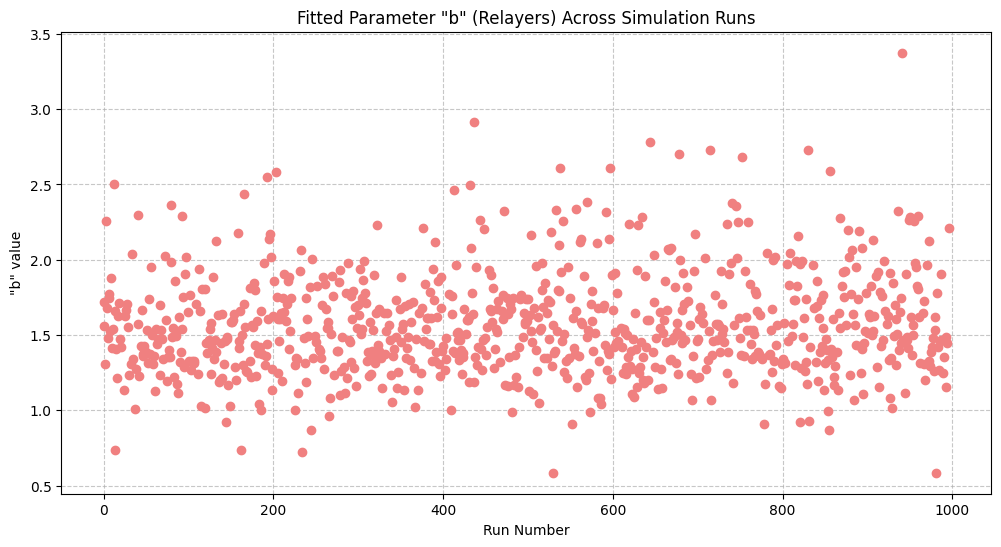

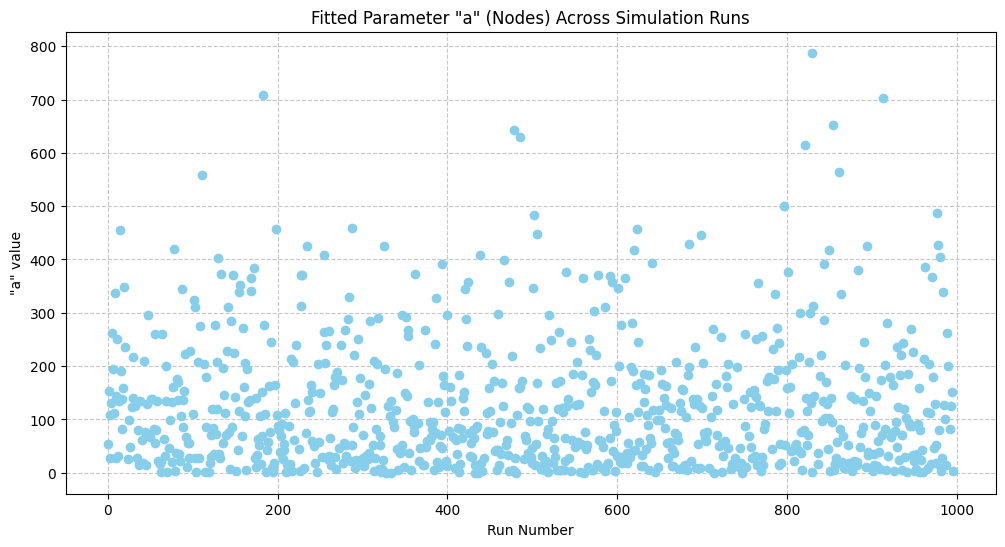

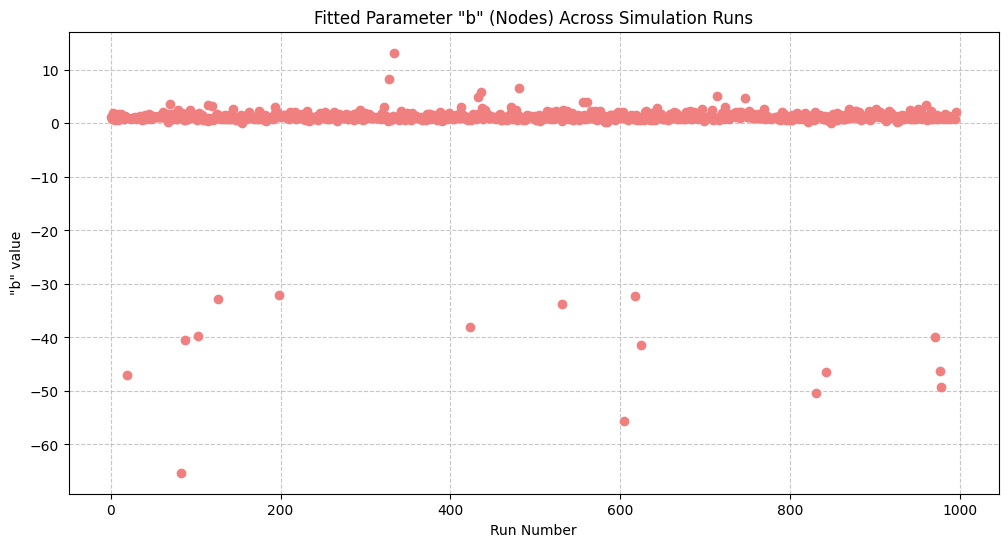

In [ ]:
from plotPowerFunctionScatter import plotPowerFunctionScatter

plotPowerFunctionScatter(runs)


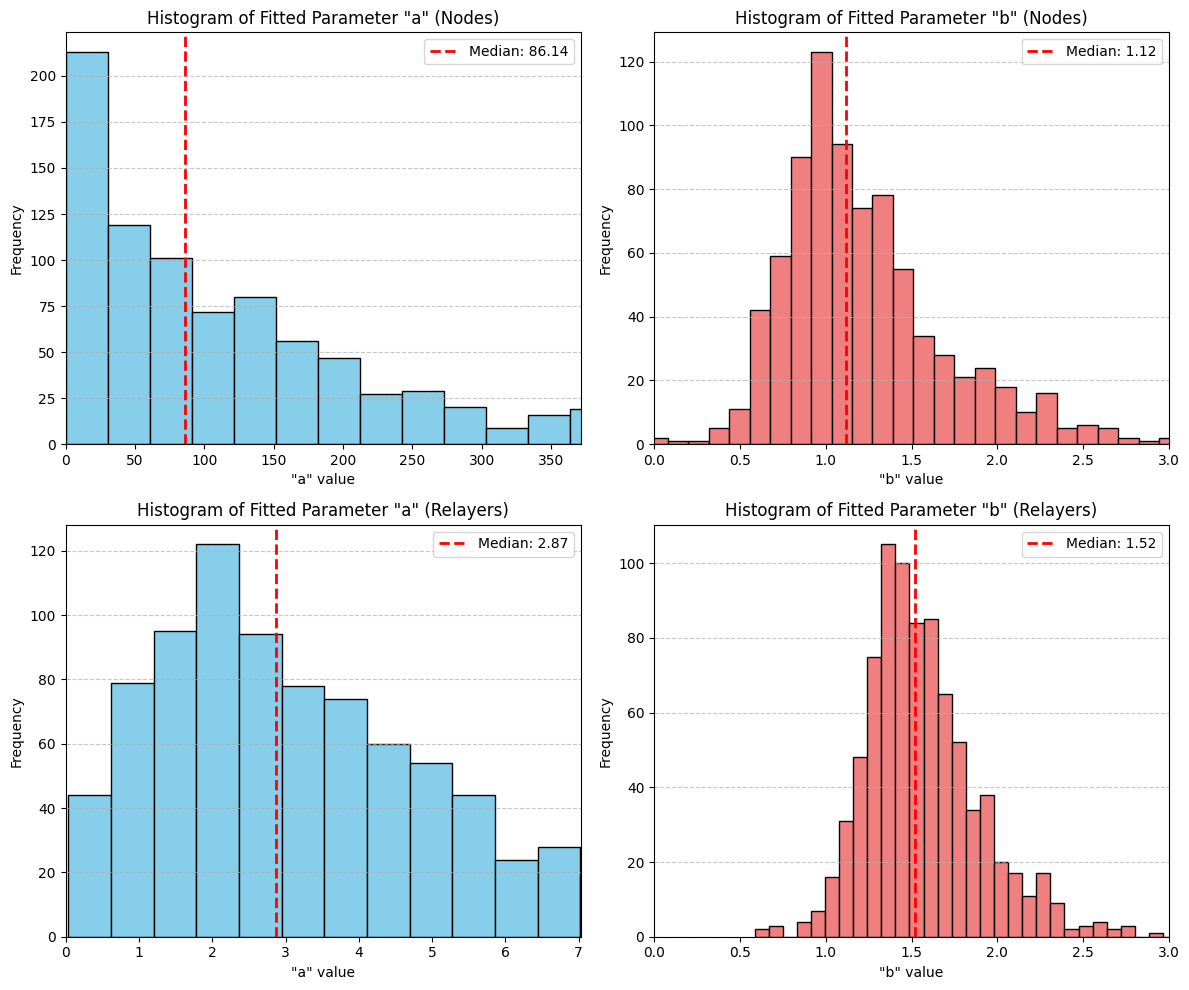

(np.float64(2.8736683773432197),
 np.float64(1.5177346133522387),
 np.float64(86.13595790838592),
 np.float64(1.1192143780995099))

In [ ]:
from plotPowerFunctionHistograms import plotPowerFunctionHistograms

plotPowerFunctionHistograms(runs)

In [ ]:
from ipywidgets import IntSlider, interact
from IPython.display import display
import time # Import the time module

def visualize_run(run_index):
  """Visualizes the propagation and hop distance behavior for a selected run."""
  if 0 <= run_index < len(runs):
    selected_run = runs[run_index]
    nodes = selected_run['nodes']

    # Time visualizePropagation
    start_time_prop = time.time()
    visualizePropagation(nodes)
    end_time_prop = time.time()
    print(f"visualizePropagation execution time: {end_time_prop - start_time_prop:.2f} seconds")

    # Time visualizeChannelUtilization
    start_time_util = time.time()
    visualizeChannelUtilization_fast(nodes)
    end_time_util = time.time()
    print(f"visualizeChannelUtilization_fast execution time: {end_time_util - start_time_util:.2f} seconds")

    # Time fit_hop_distance_behaviour
    start_time_fit = time.time()
    fit_hop_distance_behaviour(nodes, plot=True)
    end_time_fit = time.time()
    print(f"fit_hop_distance_behaviour execution time: {end_time_fit - start_time_fit:.2f} seconds")

  else:
    print("Invalid run index.")

# Create an integer slider for selecting the run index
# Add layout to make the slider wider
run_slider = IntSlider(min=0, max=len(runs)-1, step=1, description='Select Run Index:', layout={'width': '800px'})


# Use interact to link the slider to the visualization function
interact(visualize_run, run_index=run_slider, continuous_update=False);

interactive(children=(IntSlider(value=0, description='Select Run Index:', layout=Layout(width='800px'), max=99…